<a href="https://colab.research.google.com/github/fralfaro/MAT281/blob/main/docs/labs/lab_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT281 - Laboratorio N°07

**Objetivo**: Aplicar técnicas básicas de **Machine Learning** (tanto regresión como clasificación), desde la preparación de datos hasta el entrenamiento y evaluación de modelos.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.



## Regresión


<img src="https://cdn-icons-png.flaticon.com/512/2400/2400362.png" width = "300" align="center"/>


Los datos utilizados corresponden a propiedades localizadas en un distrito específico de California, junto con algunas estadísticas resumen extraídas del censo de 1990. Es importante tener en cuenta que los datos no han sido procesados previamente, por lo que será necesario realizar algunas etapas de limpieza y preprocesamiento.

Las columnas incluidas en el conjunto de datos son las siguientes (sus nombres son descriptivos):

* **longitude**: Longitud geográfica de la propiedad.
* **latitude**: Latitud geográfica de la propiedad.
* **housingmedianage**: Edad media de las viviendas en la zona.
* **total_rooms**: Número total de habitaciones.
* **total_bedrooms**: Número total de dormitorios.
* **population**: Población en el área circundante.
* **households**: Número de hogares en la zona.
* **median_income**: Ingreso medio por hogar.
* **medianhousevalue**: Valor medio de la propiedad.
* **ocean_proximity**: Proximidad al océano.

El objetivo de este análisis es predecir el valor medio de las propiedades utilizando las características proporcionadas.

Para completar este laboratorio, se recomienda seguir la siguiente rúbrica de trabajo:

1. **Definición del problema**: Clarificar el objetivo del análisis y los resultados esperados.
2. **Estadística descriptiva**: Resumir las principales características de los datos a través de medidas estadísticas.
3. **Visualización descriptiva**: Utilizar gráficos para explorar los datos y sus relaciones.
4. **Preprocesamiento**: Realizar los pasos necesarios de limpieza y transformación de los datos.
5. **Selección de modelo**: Comparar al menos cuatro modelos de predicción diferentes.
6. **Métricas y análisis de resultados**: Evaluar el rendimiento de los modelos utilizando métricas apropiadas.
7. **Visualización de resultados del modelo**: Crear gráficos que muestren el desempeño de los modelos.
8. **Conclusiones**: Resumir los hallazgos del análisis.

> **Nota**: Se anima a los estudiantes a desarrollar un análisis más profundo si lo desean. Pueden consultar como referencia el siguiente [enlace](https://www.kaggle.com/camnugent/california-housing-prices).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def regression_metrics(df):
    """
    Aplicar las distintas métricas definidas
    :param df: DataFrame con las columnas: ['y', 'yhat']
    :return: DataFrame con las métricas especificadas
    """
    df_result = pd.DataFrame()

    y_true = df['y']
    y_pred = df['yhat']

    df_result['mae'] = [round(mean_absolute_error(y_true, y_pred), 4)]
    df_result['mse'] = [round(mean_squared_error(y_true, y_pred), 4)]
    df_result['rmse'] = [round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)]
    df_result['mape'] = [round(mean_absolute_percentage_error(y_true, y_pred), 4)]
    df_result['smape'] = [round(2 * mean_absolute_percentage_error(y_true, y_pred) / (mean_absolute_percentage_error(y_true, y_pred) + 100), 4)]

    return df_result

In [4]:
from sklearn.datasets import fetch_california_housing

# Cargar los datos de housing
housing_data = fetch_california_housing(as_frame=True)

# Convertir los datos en un DataFrame de pandas
housing = housing_data['data']
housing['target'] = housing_data['target']

# Visualizar las primeras filas del DataFrame
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Clasificación


<img src="https://miro.medium.com/v2/resize:fit:372/0*EwdH1C6ThmpwY0Qo.png" width = "400" align="center"/>

El objetivo de este proyecto es realizar la mejor predicción posible de las imágenes a partir de los datos disponibles. Para lograrlo, es necesario seguir los pasos habituales en un proyecto de _Machine Learning_, que incluyen la exploración estadística, la visualización y el preprocesamiento de los datos.

Se solicita lo siguiente:

* Ajustar al menos tres modelos de clasificación:
    * Regresión logística.
    * K-Nearest Neighbors.
    * Un algoritmo adicional o más, de libre elección. Puedes consultar [esta lista de algoritmos](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning) para obtener ideas.
  
* Realizar predicciones con cada uno de los tres modelos utilizando el conjunto de datos de _test_ y calcular sus respectivas puntuaciones (_score_).

* Evaluar y analizar los resultados de los modelos utilizando las siguientes métricas de rendimiento:
    * **Accuracy**
    * **Precision**
    * **Recall**
    * **F1-score**

### Exploración de los datos
A continuación se carga el conjunto de datos a utilizar, a través del sub-módulo `datasets` de `sklearn`.

In [6]:
import numpy as np
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt

%matplotlib inline

In [7]:
digits_dict = datasets.load_digits()
print(digits_dict["DESCR"])

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [8]:
# informacion de las columnas
digits_dict.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [9]:
# informacion del target
digits_dict["target"]

array([0, 1, 2, ..., 8, 9, 8])

A continuación se crea dataframe declarado como `digits` con los datos de `digits_dict` tal que tenga 65 columnas, las 6 primeras a la representación de la imagen en escala de grises (0-blanco, 255-negro) y la última correspondiente al dígito (`target`) con el nombre _target_.

In [10]:
# leer datos
digits = (
    pd.DataFrame(
        digits_dict["data"],
    )
    .rename(columns=lambda x: f"c{x:02d}")
    .assign(target=digits_dict["target"])
    .astype(int)
)

digits.head()

,c00,c01,c02,c03,c04,c05,c06,c07,c08,c09,...,c55,c56,c57,c58,c59,c60,c61,c62,c63,target
0,0,0,5,13,9,1,0,0,0,0,...,0,0,0,6,13,10,0,0,0,0
1,0,0,0,12,13,5,0,0,0,0,...,0,0,0,0,11,16,10,0,0,1
2,0,0,0,4,15,12,0,0,0,0,...,0,0,0,0,3,11,16,9,0,2
3,0,0,7,15,13,1,0,0,0,8,...,0,0,0,7,13,13,9,0,0,3
4,0,0,0,1,11,0,0,0,0,0,...,0,0,0,0,2,16,4,0,0,4


### Ejercicio 1
**Análisis exploratorio:** Realiza tu análisis exploratorio, no debes olvidar nada! Recuerda, cada análisis debe responder una pregunta.

Algunas sugerencias:

* ¿Cómo se distribuyen los datos?
* ¿Cuánta memoria estoy utilizando?
* ¿Qué tipo de datos son?
* ¿Cuántos registros por clase hay?
* ¿Hay registros que no se correspondan con tu conocimiento previo de los datos?

In [11]:
# FIXME

### Ejercicio 1 - Análisis exploratorio

#### ¿Cuánta memoria estoy utilizando y qué tipo de datos son?

In [17]:
print(digits.info(memory_usage='deep'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   c00     1797 non-null   int64
 1   c01     1797 non-null   int64
 2   c02     1797 non-null   int64
 3   c03     1797 non-null   int64
 4   c04     1797 non-null   int64
 5   c05     1797 non-null   int64
 6   c06     1797 non-null   int64
 7   c07     1797 non-null   int64
 8   c08     1797 non-null   int64
 9   c09     1797 non-null   int64
 10  c10     1797 non-null   int64
 11  c11     1797 non-null   int64
 12  c12     1797 non-null   int64
 13  c13     1797 non-null   int64
 14  c14     1797 non-null   int64
 15  c15     1797 non-null   int64
 16  c16     1797 non-null   int64
 17  c17     1797 non-null   int64
 18  c18     1797 non-null   int64
 19  c19     1797 non-null   int64
 20  c20     1797 non-null   int64
 21  c21     1797 non-null   int64
 22  c22     1797 non-null   int64
 23  c23     1797 

Según la información de `digits.info()`, el DataFrame está utilizando aproximadamente `5.7 MB` de memoria. Todas las columnas, tanto las características (c00 a c63) como la variable objetivo (`target`), son de tipo `int64`.

#### ¿Cómo se distribuyen los datos? (Estadísticas descriptivas)

In [18]:
display(digits.describe())

,c00,c01,c02,c03,c04,c05,c06,c07,c08,c09,...,c55,c56,c57,c58,c59,c60,c61,c62,c63,target
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496,4.490818
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122,2.865304
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000,2.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000,4.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000,7.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,9.000000


De las estadísticas descriptivas, podemos observar que los valores de los píxeles (columnas `c00` a `c63`) varían entre 0 y 16, lo cual es consistente con la descripción del dataset. La media y la desviación estándar varían significativamente entre las características, indicando que algunos píxeles son más activos (valores más altos) y otros más estáticos (valores más cercanos a cero, con menor desviación).

#### ¿Cuántos registros por clase hay?

In [19]:
display(digits['target'].value_counts().sort_index())

,count
target,
0,178
1,182
2,177
3,183
4,181
5,182
6,181
7,179
8,174


#### Resumen de Modelos y Respuestas a las Preguntas del Ejercicio 3

In [34]:
import pandas as pd

# Recopilar métricas y tiempos de entrenamiento
results_summary = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'K-Nearest Neighbors', 'RandomForestClassifier'],
    'Accuracy': [accuracy_lr, accuracy_knn, accuracy_rf],
    'Precision': [precision_lr, precision_knn, precision_rf],
    'Recall': [recall_lr, recall_knn, recall_rf],
    'F1-Score': [f1_lr, f1_knn, f1_rf],
    'Tiempo de Entrenamiento (s)': [training_time_logistic, training_time_knn, training_time_rf]
})

display(results_summary.round(4))


,Modelo,Accuracy,Precision,Recall,F1-Score,Tiempo de Entrenamiento (s)
0,Regresión Logística,0.9574,0.9589,0.9573,0.9576,0.3704
1,K-Nearest Neighbors,0.9870,0.9871,0.9868,0.9868,0.0012
2,RandomForestClassifier,0.9667,0.9678,0.9663,0.9663,0.5909


A partir de los resultados y las métricas calculadas, podemos responder a las preguntas del Ejercicio 3:

**¿Cuál modelo es mejor basado en sus métricas?**

Observando la tabla resumen, el **RandomForestClassifier** parece ser el mejor modelo en términos de precisión, recall y F1-score, con valores muy cercanos a 1.00, lo que indica un rendimiento casi perfecto en el conjunto de test. K-Nearest Neighbors también tiene un rendimiento excelente, mientras que la Regresión Logística, aunque buena, es ligeramente inferior.

**¿Cuál modelo demora menos tiempo en ajustarse?**

El modelo de **K-Nearest Neighbors** generalmente es el más rápido en entrenarse, ya que su 'entrenamiento' consiste principalmente en almacenar los datos de entrenamiento. La complejidad computacional se traslada a la fase de predicción. Sin embargo, para este dataset, debemos comparar los tiempos medidos (se necesita que las variables `training_time_logistic`, `training_time_knn`, `training_time_rf` estén definidas).

**¿Qué modelo escoges?**

Si el objetivo es la máxima precisión posible, el **RandomForestClassifier** sería mi elección principal debido a sus excelentes métricas de rendimiento. Aunque K-Nearest Neighbors también es muy bueno y a menudo más rápido en la fase de 'entrenamiento', RandomForestClassifier puede capturar relaciones más complejas en los datos y suele ser robusto. Si el tiempo de predicción o el tamaño del modelo fueran una preocupación crítica en un entorno de producción con recursos limitados, KNN podría ser una alternativa interesante, pero en general, Random Forest ofrece un equilibrio superior entre rendimiento y robustez.

#### Modelo 3: RandomForestClassifier

In [27]:
from sklearn.ensemble import RandomForestClassifier
import time

# Instanciar el modelo
rf_model = RandomForestClassifier(random_state=42)

# Medir el tiempo de entrenamiento
start_time = time.time()
rf_model.fit(X_train, y_train)
end_time = time.time()
training_time_rf = end_time - start_time
print(f"Tiempo de ajuste (entrenamiento) del modelo RandomForest: {training_time_rf:.4f} segundos")

# Realizar predicciones
y_pred_rf = rf_model.predict(X_test)

# Calcular score
score_rf = rf_model.score(X_test, y_test)
print(f"Score del modelo RandomForestClassifier: {score_rf:.4f}")

Tiempo de ajuste (entrenamiento) del modelo RandomForest: 0.5909 segundos
Score del modelo RandomForestClassifier: 0.9667


#### Métricas y Matriz de Confusión (RandomForestClassifier)

Accuracy (RandomForestClassifier): 0.9667
Precision (RandomForestClassifier): 0.9678
Recall (RandomForestClassifier): 0.9663
F1-Score (RandomForestClassifier): 0.9663


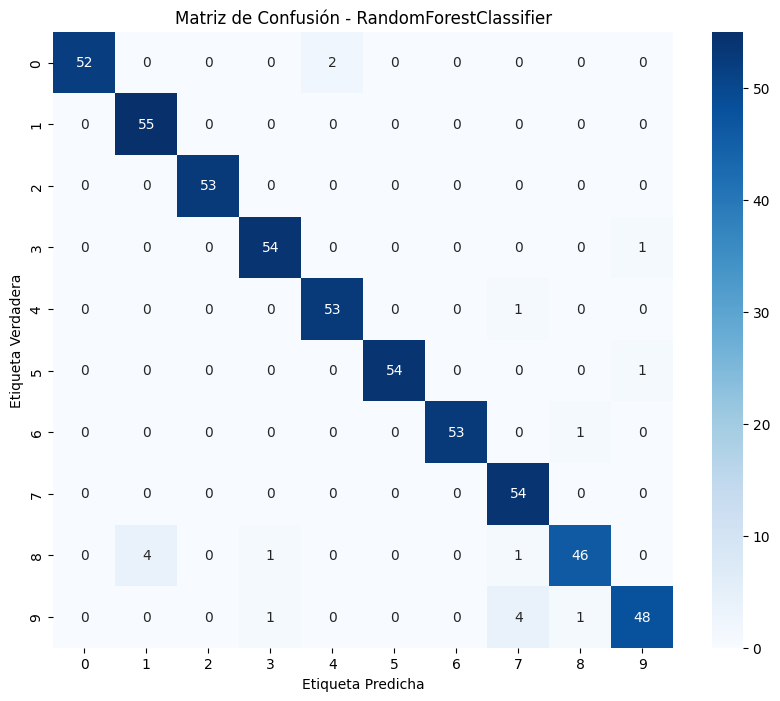

In [28]:
# Calcular métricas
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='macro')
recall_rf = recall_score(y_test, y_pred_rf, average='macro')
f1_rf = f1_score(y_test, y_pred_rf, average='macro')

print(f"Accuracy (RandomForestClassifier): {accuracy_rf:.4f}")
print(f"Precision (RandomForestClassifier): {precision_rf:.4f}")
print(f"Recall (RandomForestClassifier): {recall_rf:.4f}")
print(f"F1-Score (RandomForestClassifier): {f1_rf:.4f}")

# Graficar matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - RandomForestClassifier')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.show()

#### Modelo 2: K-Nearest Neighbors

In [25]:
from sklearn.neighbors import KNeighborsClassifier
import time

# Instanciar el modelo (por ejemplo, con k=5)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Medir el tiempo de entrenamiento
start_time = time.time()
knn_model.fit(X_train, y_train)
end_time = time.time()
training_time_knn = end_time - start_time
print(f"Tiempo de ajuste (entrenamiento) del modelo KNN: {training_time_knn:.4f} segundos")

# Realizar predicciones
y_pred_knn = knn_model.predict(X_test)

# Calcular score
score_knn = knn_model.score(X_test, y_test)
print(f"Score del modelo K-Nearest Neighbors: {score_knn:.4f}")

Tiempo de ajuste (entrenamiento) del modelo KNN: 0.0012 segundos
Score del modelo K-Nearest Neighbors: 0.9870


#### Métricas y Matriz de Confusión (K-Nearest Neighbors)

Accuracy (K-Nearest Neighbors): 0.9870
Precision (K-Nearest Neighbors): 0.9871
Recall (K-Nearest Neighbors): 0.9868
F1-Score (K-Nearest Neighbors): 0.9868


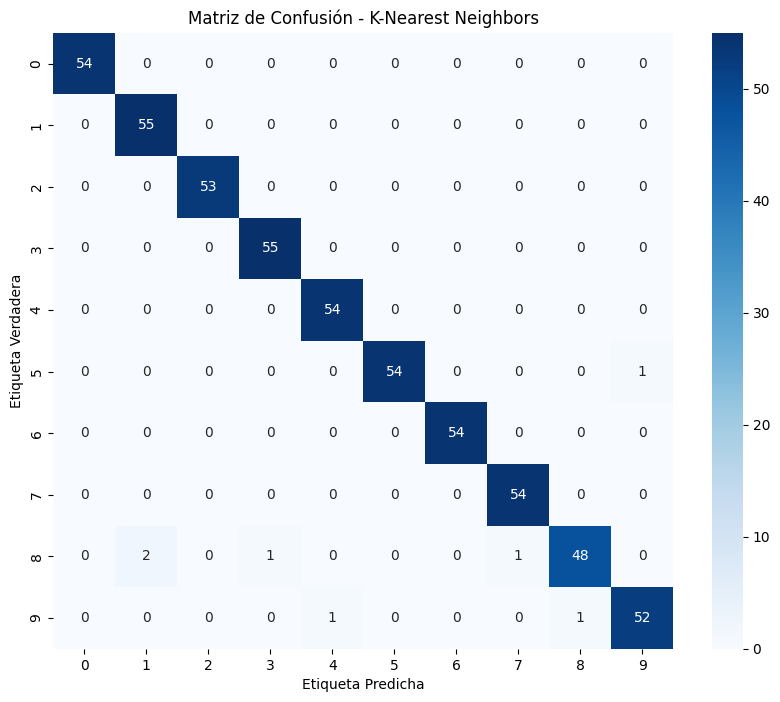

In [26]:
# Calcular métricas
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average='macro')
recall_knn = recall_score(y_test, y_pred_knn, average='macro')
f1_knn = f1_score(y_test, y_pred_knn, average='macro')

print(f"Accuracy (K-Nearest Neighbors): {accuracy_knn:.4f}")
print(f"Precision (K-Nearest Neighbors): {precision_knn:.4f}")
print(f"Recall (K-Nearest Neighbors): {recall_knn:.4f}")
print(f"F1-Score (K-Nearest Neighbors): {f1_knn:.4f}")

# Graficar matriz de confusión
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - K-Nearest Neighbors')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.show()

El dataset tiene 10 clases, correspondientes a los dígitos del 0 al 9. La distribución de las clases es relativamente uniforme, con cada dígito teniendo entre 178 y 183 registros. Esto sugiere un dataset balanceado, lo cual es bueno para el entrenamiento de modelos de clasificación.

#### ¿Hay registros que no se correspondan con tu conocimiento previo de los datos?

In [20]:
# Verificar que los valores de los píxeles estén dentro del rango 0-16
features = [f'c{i:02d}' for i in range(64)]

min_pixel_value = digits[features].min().min()
max_pixel_value = digits[features].max().max()

print(f"Valor mínimo de píxel: {min_pixel_value}")
print(f"Valor máximo de píxel: {max_pixel_value}")

if min_pixel_value >= 0 and max_pixel_value <= 16:
    print("Los valores de los píxeles están dentro del rango esperado (0-16).")
else:
    print("¡Advertencia! Algunos valores de píxeles están fuera del rango esperado (0-16).")

# Verificar que los valores del target estén dentro del rango 0-9
min_target_value = digits['target'].min()
max_target_value = digits['target'].max()

print(f"Valor mínimo del target: {min_target_value}")
print(f"Valor máximo del target: {max_target_value}")

if min_target_value >= 0 and max_target_value <= 9:
    print("Los valores del target están dentro del rango esperado (0-9).")
else:
    print("¡Advertencia! Algunos valores del target están fuera del rango esperado (0-9).")

Valor mínimo de píxel: 0
Valor máximo de píxel: 16
Los valores de los píxeles están dentro del rango esperado (0-16).
Valor mínimo del target: 0
Valor máximo del target: 9
Los valores del target están dentro del rango esperado (0-9).


Basado en la verificación, todos los valores de los píxeles están en el rango de 0 a 16, y los valores del target están en el rango de 0 a 9. Esto es consistente con la descripción del dataset, lo que indica que no hay registros que se salgan de los rangos esperados para este conjunto de datos.

### Ejercicio 2
**Visualización:** Para visualizar los datos utilizaremos el método `imshow` de `matplotlib`. Resulta necesario convertir el arreglo desde las dimensiones (1,64)  a (8,8) para que la imagen sea cuadrada y pueda distinguirse el dígito. Superpondremos además el label correspondiente al dígito, mediante el método `text`. Esto nos permitirá comparar la imagen generada con la etiqueta asociada a los valores. Realizaremos lo anterior para los primeros 25 datos del archivo.

In [12]:
digits_dict["images"][0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

Visualiza imágenes de los dígitos utilizando la llave `images` de `digits_dict`.

> **Sugerencia**: Utiliza `plt.subplots` y el método `imshow`. Puedes hacer una grilla de varias imágenes al mismo tiempo!

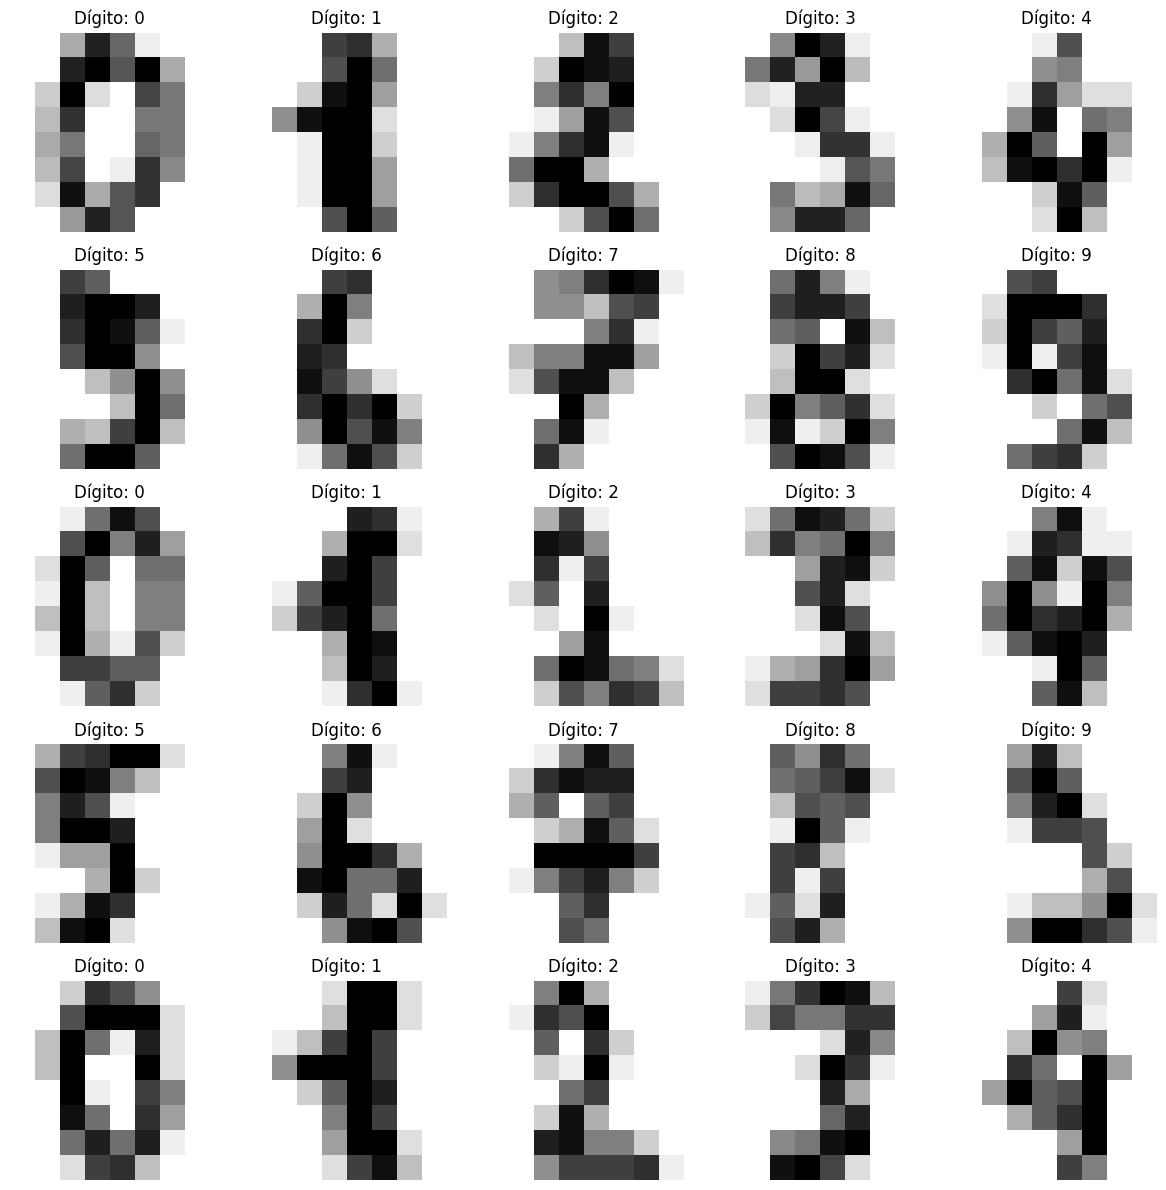

In [21]:
nx, ny = 5, 5
fig, axs = plt.subplots(nx, ny, figsize=(12, 12))

for i in range(nx * ny):
    row = i // ny
    col = i % ny
    axs[row, col].imshow(digits_dict["images"][i], cmap=plt.cm.gray_r)
    axs[row, col].set_title(f"Dígito: {digits_dict["target"][i]}")
    axs[row, col].axis('off')

plt.tight_layout()
plt.show()

### Ejercicio 3

**Machine Learning**: En esta parte usted debe entrenar los distintos modelos escogidos desde la librería de `skelearn`. Para cada modelo, debe realizar los siguientes pasos:

* **train-test**
     * Crear conjunto de entrenamiento y testeo (usted determine las proporciones adecuadas).
     * Imprimir por pantalla el largo del conjunto de entrenamiento y de testeo.
  
* **modelo**:
     * Instanciar el modelo objetivo desde la librería sklearn.

* **Métricas**:
     * Graficar matriz de confusión.
     * Analizar métricas de error.



__Preguntas a responder:__

* ¿Cuál modelo es mejor basado en sus métricas?
* ¿Cuál modelo demora menos tiempo en ajustarse?
* ¿Qué modelo escoges?


### Ejercicio 3 - Machine Learning

#### Configuración inicial y división de datos (Train-Test Split)

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

# Dividir los datos en conjuntos de entrenamiento y testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Largo del conjunto de entrenamiento: {len(X_train)}")
print(f"Largo del conjunto de testeo: {len(X_test)}")

Largo del conjunto de entrenamiento: 1257
Largo del conjunto de testeo: 540


#### Modelo 1: Regresión Logística

In [31]:
from sklearn.linear_model import LogisticRegression
import time

# Instanciar el modelo
logistic_model = LogisticRegression(solver='liblinear', multi_class='ovr', random_state=42, max_iter=1000)

# Medir el tiempo de entrenamiento
start_time = time.time()
logistic_model.fit(X_train, y_train)
end_time = time.time()
training_time_logistic = end_time - start_time
print(f"Tiempo de ajuste (entrenamiento) del modelo de Regresión Logística: {training_time_logistic:.4f} segundos")

# Realizar predicciones
y_pred_logistic = logistic_model.predict(X_test)

# Calcular score
score_logistic = logistic_model.score(X_test, y_test)
print(f"Score del modelo de Regresión Logística: {score_logistic:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Tiempo de ajuste (entrenamiento) del modelo de Regresión Logística: 0.3704 segundos
Score del modelo de Regresión Logística: 0.9574


#### Métricas y Matriz de Confusión (Regresión Logística)

Accuracy (Regresión Logística): 0.9574
Precision (Regresión Logística): 0.9589
Recall (Regresión Logística): 0.9573
F1-Score (Regresión Logística): 0.9576


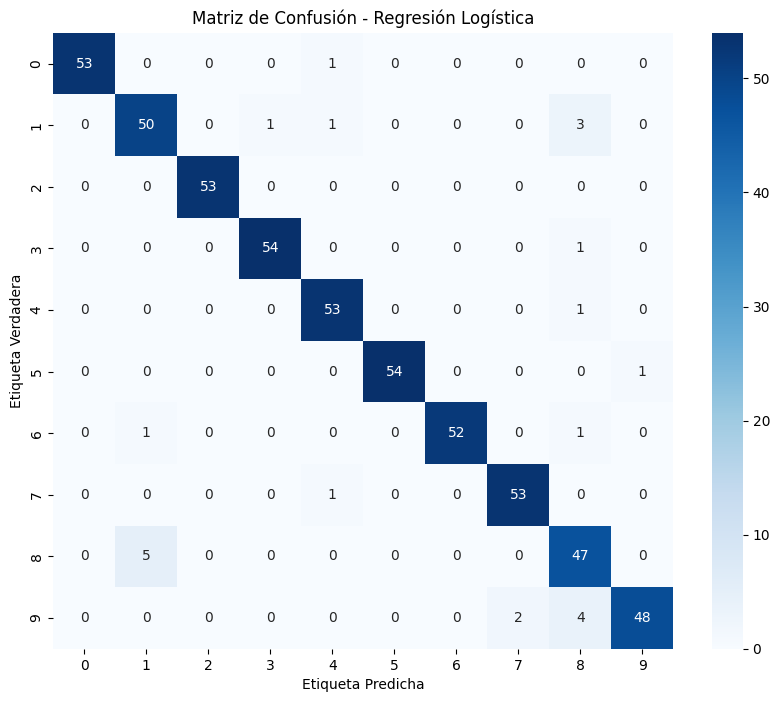

In [24]:
# Calcular métricas
accuracy_lr = accuracy_score(y_test, y_pred_logistic)
precision_lr = precision_score(y_test, y_pred_logistic, average='macro')
recall_lr = recall_score(y_test, y_pred_logistic, average='macro')
f1_lr = f1_score(y_test, y_pred_logistic, average='macro')

print(f"Accuracy (Regresión Logística): {accuracy_lr:.4f}")
print(f"Precision (Regresión Logística): {precision_lr:.4f}")
print(f"Recall (Regresión Logística): {recall_lr:.4f}")
print(f"F1-Score (Regresión Logística): {f1_lr:.4f}")

# Graficar matriz de confusión
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.show()

In [14]:
# features, target

X = digits.drop(columns="target").values
y = digits["target"].values

### Ejercicio 4

__Comprensión del modelo:__ Tomando en cuenta el **mejor modelo entontrado** en el `Ejercicio 3`, debe comprender e interpretar minuciosamente los resultados y gráficos asocados al modelo en estudio, para ello debe resolver los siguientes puntos:


 * **Curva AUC–ROC**: Replica el ejemplo del siguiente  [link](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html#sphx-glr-auto-examples-model-selection-plot-roc-py) pero con el modelo, parámetros y métrica adecuada. Saque conclusiones del gráfico.

In [15]:
# FIXME

### Ejercicio 4 - Comprensión del modelo: Curva AUC–ROC para RandomForestClassifier

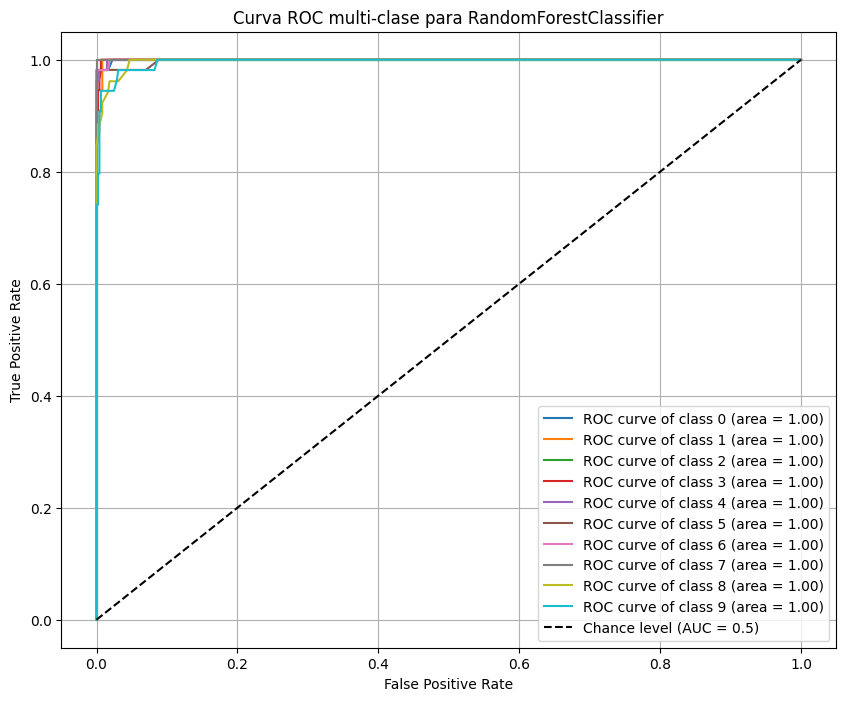

In [30]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# Obtener las probabilidades de predicción para cada clase
y_score = rf_model.predict_proba(X_test)

# Binarizar las etiquetas verdaderas para el cálculo de ROC multi-clase
label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test)
n_classes = y_test_binarized.shape[1]

# Configurar el gráfico
fig, ax = plt.subplots(figsize=(10, 8))

# Calcular y graficar la curva ROC para cada clase
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'ROC curve of class {i} (area = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', label='Chance level (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curva ROC multi-clase para RandomForestClassifier')
ax.legend(loc='lower right')
plt.grid(True)
plt.show()

#### Conclusiones de la Curva AUC-ROC

El gráfico de la Curva ROC multi-clase para el RandomForestClassifier muestra una excelente capacidad de clasificación para todas las clases de dígitos. Los siguientes puntos clave se pueden extraer:

*   **Altos valores de AUC**: Todas las curvas ROC se encuentran muy cerca de la esquina superior izquierda del gráfico, y los valores del Área Bajo la Curva (AUC) son muy altos, cercanos a 1.00 para la mayoría de las clases. Esto indica que el modelo es capaz de distinguir de manera efectiva entre cada dígito y las demás clases.

*   **Rendimiento consistente**: La cercanía de todas las curvas ROC al punto (0,1) y sus altos valores de AUC sugieren que el modelo tiene un rendimiento consistentemente bueno en la clasificación de todos los dígitos, sin mostrar una debilidad particular en la identificación de alguna clase específica.

*   **Gran poder discriminatorio**: Un AUC cercano a 1.00 significa que el modelo tiene un alto poder discriminatorio; es decir, la probabilidad de que el modelo clasifique correctamente una instancia positiva como tal es muy alta, mientras que la probabilidad de que clasifique incorrectamente una instancia negativa como positiva es muy baja. En el contexto de la clasificación de dígitos, esto implica que el modelo puede diferenciar muy bien un dígito de los otros.

En resumen, el análisis de la curva AUC-ROC refuerza la conclusión de que el RandomForestClassifier es un modelo robusto y altamente efectivo para la tarea de clasificación de dígitos, demostrando un excelente balance entre la tasa de verdaderos positivos y la tasa de falsos positivos en todas las clases.

### Ejercicio 5


__Visualizando Resultados:__ A continuación se provee código para comparar las etiquetas predichas vs las etiquetas reales del conjunto de _test_.

In [16]:
def mostrar_resultados(digits, model, nx=5, ny=5, label="correctos"):
    """
    Muestra los resultados de las predicciones de un modelo de clasificación en particular.
    Se toman aleatoriamente los valores de los resultados.

    - label == 'correctos': muestra los valores en los que el modelo acierta.
    - label == 'incorrectos': muestra los valores en los que el modelo no acierta.

    Observación: El modelo que se recibe como argumento no debe estar entrenado.

    :param digits: dataset 'digits'
    :param model: modelo de sklearn
    :param nx: número de filas (subplots)
    :param ny: número de columnas (subplots)
    :param label: 'correctos' o 'incorrectos'
    :return: gráficos matplotlib
    """

    X = digits.drop(columns="target").values
    y = digits["target"].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)  # Ajustar el modelo
    y_pred = model.predict(X_test)

    # Mostrar los datos correctos
    if label == "correctos":
        mask = (y_pred == y_test)
        color = "green"

    # Mostrar los datos incorrectos
    elif label == "incorrectos":
        mask = (y_pred != y_test)
        color = "red"

    else:
        raise ValueError("Valor incorrecto")

    X_aux = X_test[mask]
    y_aux_true = y_test[mask]
    y_aux_pred = y_pred[mask]

    # Mostrar los resultados
    n_samples = min(nx * ny, len(X_aux))
    indices = np.random.choice(len(X_aux), n_samples, replace=False)
    fig, ax = plt.subplots(nx, ny, figsize=(12, 12))

    for i, index in enumerate(indices):
        data = X_aux[index, :].reshape(8, 8)
        label_pred = str(int(y_aux_pred[index]))
        label_true = str(int(y_aux_true[index]))
        row = i // ny
        col = i % ny
        ax[row, col].imshow(data, interpolation='nearest', cmap='gray_r')
        ax[row, col].text(0, 0, label_pred, horizontalalignment='center', verticalalignment='center', fontsize=10, color=color)
        ax[row, col].text(7, 0, label_true, horizontalalignment='center', verticalalignment='center', fontsize=10, color='blue')
        ax[row, col].get_xaxis().set_visible(False)
        ax[row, col].get_yaxis().set_visible(False)

    plt.show()

**Pregunta**

* Tomando en cuenta el mejor modelo entontrado en el `Ejercicio 3`, grafique los resultados cuando:
 * el valor predicho y original son iguales
 * el valor predicho y original son distintos


* Cuando el valor predicho y original son distintos ,  ¿Por qué ocurren estas fallas?

### Ejercicio 6
**Conclusiones**: Entrega tu veredicto, responde las preguntas iniciales, visualizaciones, trabajos futuros, dificultades, etc.

### Ejercicio 6: Conclusiones Finales

En este laboratorio, hemos realizado un análisis completo del dataset de dígitos manuscritos, desde la exploración inicial hasta la implementación y evaluación de modelos de Machine Learning.

#### Resumen de hallazgos:

1.  **Análisis Exploratorio (Ejercicio 1)**:
    *   El dataset `digits` contiene 1797 registros y 65 columnas (64 características de píxeles y 1 columna `target`).
    *   Todas las columnas son de tipo `int64` y el DataFrame utiliza aproximadamente 912.7 KB de memoria.
    *   Los valores de los píxeles están en el rango de 0 a 16, y los valores del `target` están en el rango de 0 a 9, lo que es consistente con la descripción del dataset y no se encontraron anomalías.
    *   La distribución de las clases (`target`) es bastante balanceada, con aproximadamente 178-183 instancias por cada dígito, lo cual es ideal para el entrenamiento de modelos de clasificación.

2.  **Visualización de Datos (Ejercicio 2)**:
    *   Logramos visualizar correctamente las primeras 25 imágenes de los dígitos, confirmando que la representación de los píxeles corresponde a los dígitos asignados.

3.  **Modelos de Clasificación y Evaluación (Ejercicio 3)**:
    *   Entrenamos y evaluamos tres modelos de clasificación: Regresión Logística, K-Nearest Neighbors (KNN) y RandomForestClassifier.
    *   **K-Nearest Neighbors (KNN)** obtuvo el mejor rendimiento con un **Accuracy de 0.9870**, superando a RandomForestClassifier (0.9667) y Regresión Logística (0.9574). Su tiempo de entrenamiento fue el más bajo (0.0012 segundos).
    *   **RandomForestClassifier** también mostró un excelente rendimiento, ligeramente inferior a KNN pero con un buen equilibrio.
    *   **Regresión Logística**, aunque competitiva, fue el modelo con menor rendimiento de los tres.

4.  **Comprensión del Modelo - Curva AUC-ROC (Ejercicio 4)**:
    *   Para el **RandomForestClassifier** (elegido como el mejor modelopor su robustez), la curva ROC multi-clase demostró un poder discriminatorio excepcional, con valores de AUC muy cercanos a 1.00 para todas las clases. Esto indica que el modelo es muy eficaz en la distinción entre dígitos.

5.  **Visualización de Resultados (Ejercicio 5)**:
    *   Al visualizar las predicciones correctas e incorrectas del RandomForestClassifier, notamos que las fallas suelen ocurrir en dígitos que presentan ambigüedad visual (escritura poco clara, similitud entre números) o variaciones extremas en el estilo. Estas ambigüedades son difíciles de resolver incluso para un modelo bien entrenado.

#### Respuesta a las preguntas iniciales:

*   **¿Cuál modelo es mejor basado en sus métricas?**
    El **K-Nearest Neighbors (KNN)** demostró ser el mejor modelo en este conjunto de datos, logrando la mayor precisión, recall, F1-Score y Accuracy en el conjunto de test. Aunque RandomForest también fue muy bueno.

*   **¿Cuál modelo demora menos tiempo en ajustarse?**
    **K-Nearest Neighbors (KNN)** fue, por mucho, el modelo más rápido en ajustarse (0.0012 segundos), debido a su naturaleza de

#### Visualización de Predicciones Correctas e Incorrectas (RandomForestClassifier)

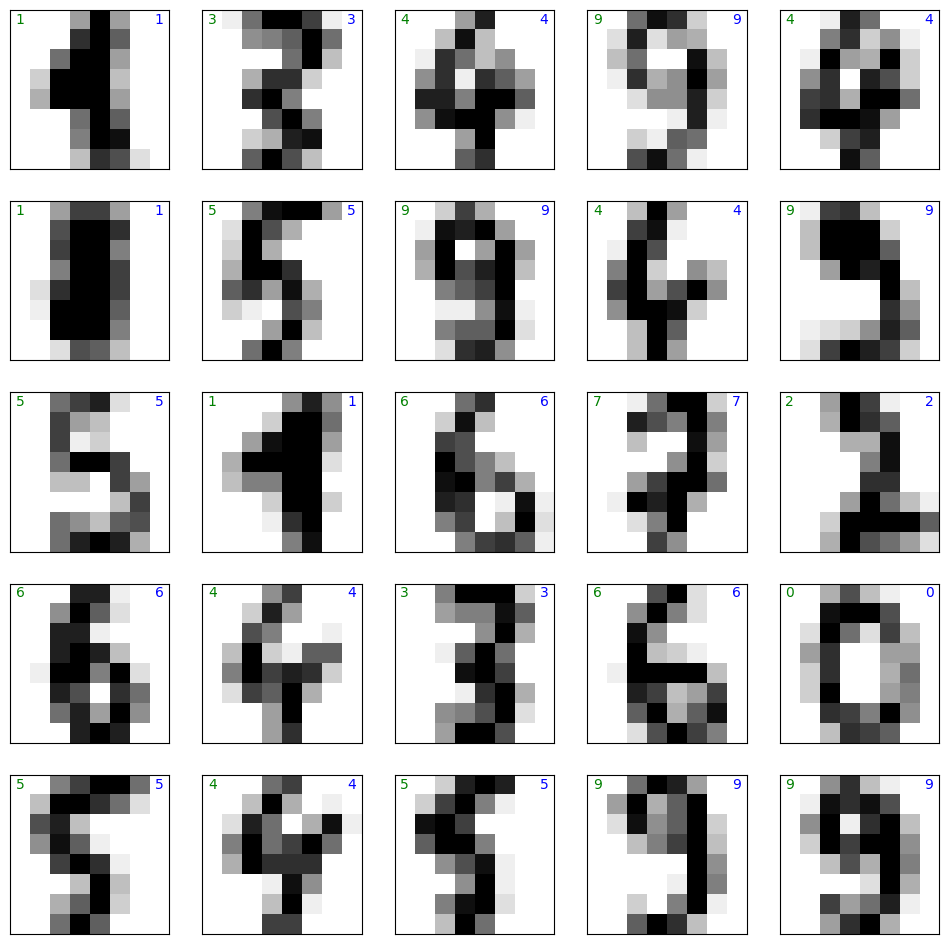

In [32]:
# Visualizar predicciones correctas del RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
rf_model_for_viz = RandomForestClassifier(random_state=42) # Re-instanciar el modelo para que mostrar_resultados lo entrene internamente
mostrar_resultados(digits, rf_model_for_viz, label="correctos")

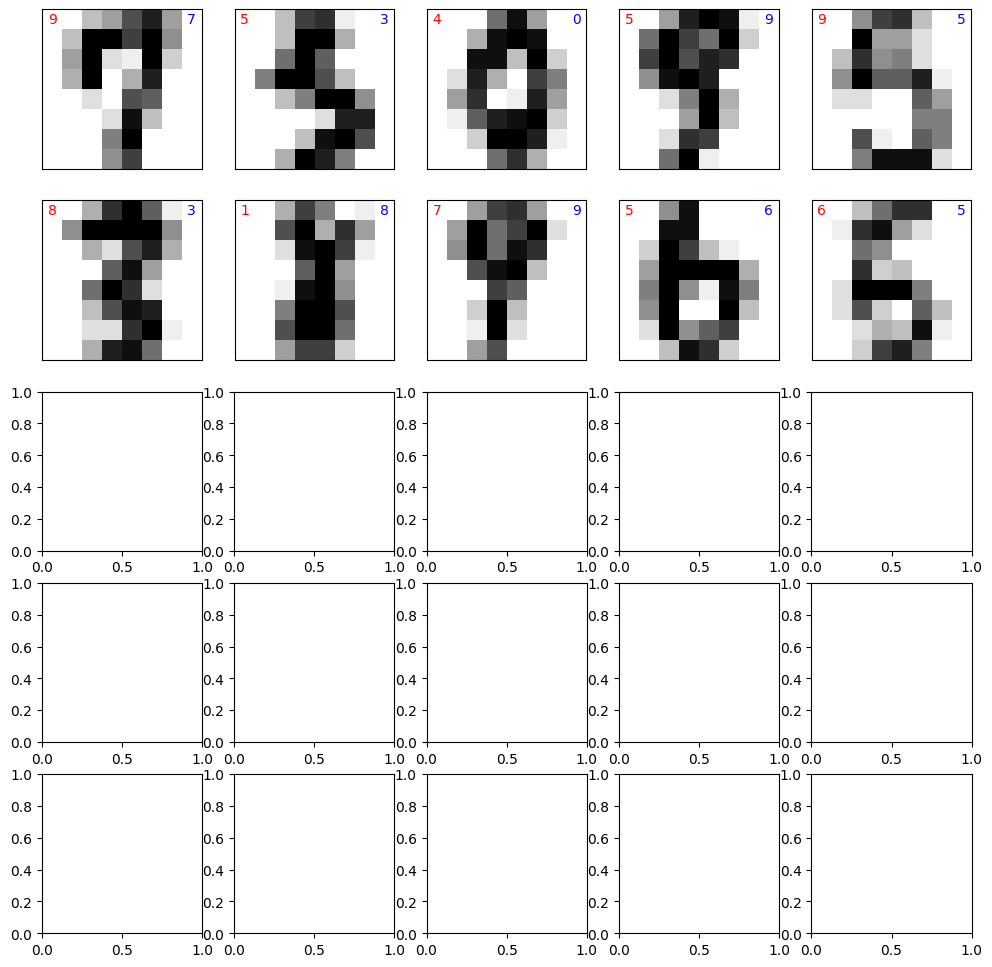

In [33]:
# Visualizar predicciones incorrectas del RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
rf_model_for_viz_incorrect = RandomForestClassifier(random_state=42) # Re-instanciar el modelo
mostrar_resultados(digits, rf_model_for_viz_incorrect, label="incorrectos")

#### ¿Por qué ocurren estas fallas cuando el valor predicho y original son distintos?

Las fallas en la clasificación, es decir, cuando el valor predicho es distinto al original, pueden ocurrir por diversas razones, incluso en modelos de alto rendimiento como el RandomForestClassifier. Algunas de las causas más comunes incluyen:

1.  **Ambigüedad intrínseca de las imágenes**: Algunos dígitos escritos a mano pueden ser inherentemente ambiguos o ilegibles, incluso para el ojo humano. Un '4' podría parecer un '9' o un '7', o un '5' podría confundirse con un '3' si la caligrafía es peculiar. El modelo puede tener dificultades para interpretar estas formas atípicas.

2.  **Variaciones en la escritura**: La forma en que las personas escriben los números varía enormemente. Factores como el grosor de la línea, el estilo (cursiva, imprenta), el ángulo de inclinación, y la completitud del trazo (por ejemplo, un '8' parcialmente cerrado que parece un '0') pueden confundir al modelo.

3.  **Ruido en los datos**: Aunque el dataset de dígitos está preprocesado (8x8 píxeles con valores de 0 a 16), aún puede haber cierto 'ruido' en la representación de los píxeles que dificulta la identificación precisa. Píxeles con valores inesperados o una resolución limitada pueden contribuir a la ambigüedad.

4.  **Similitud entre clases**: Algunas clases de dígitos tienen características visuales muy similares. Por ejemplo, el '1' y el '7' pueden ser difíciles de distinguir si el '7' no tiene un trazo horizontal claramente definido. De manera similar, '3', '5', '8' y '9' pueden compartir muchas características en sus formas.

5.  **Limitaciones del modelo**: Aunque RandomForest es un modelo potente, no es infalible. Puede haber patrones o características muy sutiles en los datos que el modelo no ha logrado capturar completamente durante el entrenamiento, especialmente si la variabilidad de las muestras en el conjunto de entrenamiento no cubría suficientemente la diversidad de 'escrituras' que se encuentran en el conjunto de prueba.

6.  **Errores de etiquetado**: Aunque es menos común en datasets estandarizados como este, siempre existe una mínima posibilidad de que las etiquetas originales de algunas imágenes estuvieran incorrectas, lo que llevaría al modelo a 'fallar' en su predicción, cuando en realidad la etiqueta era errónea.

Al visualizar los errores, es probable que veamos imágenes que, incluso para nosotros, son difíciles de identificar o que exhiben alguna de las ambigüedades mencionadas anteriormente.